# Physics-Informed Neural Networks for Activity Coefficient Prediction

This notebook presents the development of a physics-informed neural network (PINN) to predict activity coefficients using processed experimental data. By embedding thermodynamic constraints directly into the loss function, we incorporate domain knowledge into the model, ensuring thermodynamic consistency while leveraging a data-driven approach.

## Dependencies

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from torchmetrics.regression import R2Score

## PINN modeling

### Designing the Neural Network Components

Fix the random seed to be used

In [2]:
torch.manual_seed(42)

Define the architecture of the neural network

In [3]:
class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_4(x)

        return x

Implement a custom loss function that enforces thermodynamic consistency by embedding the Gibbs-Duhem equation into the standard MSE loss

In [4]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    X: torch.Tensor,
    model: torch.nn.Module,
    lambda_gd: float = 1.0,
    lambda_l1: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Calculate ln(gamma)
    ln_gamma1 = y_pred[:, 0]
    ln_gamma2 = y_pred[:, 1]

    # Compute partial derivatives
    dgamma1_dx1 = torch.autograd.grad(
        ln_gamma1,
        X,
        grad_outputs=torch.ones_like(ln_gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    dgamma2_dx1 = torch.autograd.grad(
        ln_gamma2,
        X,
        grad_outputs=torch.ones_like(ln_gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    # Compute Gibbs-Duhem term
    x1 = X[:, 2]
    x2 = X[:, 5]
    gibbs_duhem_term = x1 * dgamma1_dx1 + x2 * dgamma2_dx1

    # Physics-based loss
    gd_loss = torch.mean(gibbs_duhem_term**2) * lambda_gd

    # L1 regularization term
    l1_loss = (sum(p.abs().sum() for p in model.parameters())) * lambda_l1

    # Total loss
    loss = mse_loss + gd_loss + l1_loss

    return loss, mse_loss, gd_loss, gibbs_duhem_term

### Reading the data

Defining the data path conveniently:

In [5]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [6]:
data = pd.read_csv(DATA_PATH / "processed" / "toy_problem_training_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,ln_gamma_1,ln_gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
10681,5.8486,4.936,0.96,4.5310,3.976,0.04,394.908,0.000950,0.662415
10682,5.8486,4.936,0.97,4.5310,3.976,0.03,395.817,0.000530,0.672245
10683,5.8486,4.936,0.98,4.5310,3.976,0.02,396.773,0.000240,0.681990
10684,5.8486,4.936,0.99,4.5310,3.976,0.01,397.779,0.000060,0.691646


### PINN training

Defining model constants

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10000
LAMBDA_GD = 1

Split the data into train and test

In [8]:
features = data.iloc[:, :-2].values
labels = data.iloc[:, -2:].values

# Separate the test data
X, X_test, y, y_test = train_test_split(
    features, labels, test_size=0.1, random_state=42
)

Defining the Optuna objective function to find the best hyperparameters

In [9]:
def objective(trial):
    # Hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    lambda_gd = LAMBDA_GD
    lambda_l1 = trial.suggest_float("lambda_l1", 1e-5, 1e-2, log=True)

    # Define the cross-validation folds
    k_folds = 5
    cv = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    val_losses = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scale the data
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Convert to tensors
        X_train_tensor = torch.tensor(
            X_train_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        X_val_tensor = torch.tensor(
            X_val_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

        # Model and optimizer
        input_size = X_train.shape[1]
        output_size = 2
        model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # Early stopping setup
        best_val_loss = float("inf")
        patience = EPOCHS / 10
        patience_counter = 0

        for epoch in range(EPOCHS):
            # Training
            model.train()
            outputs = model(X_train_tensor)
            loss = gibbs_duhem_loss(
                outputs, y_train_tensor, X_train_tensor, model, lambda_gd, lambda_l1
            )[0]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Validation
            model.eval()
            val_outputs = model(X_val_tensor)
            val_loss = gibbs_duhem_loss(
                val_outputs, y_val_tensor, X_val_tensor, model, lambda_gd, lambda_l1
            )[0]

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}. Best val loss: {best_val_loss:.4f}"
                )
                break

        val_losses.append(best_val_loss)

    return np.mean(val_losses)

Get the best hyperparameters

In [10]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)

[I 2025-07-24 19:01:08,471] A new study created in memory with name: no-name-74a74aed-87a3-4f73-8957-5c583d4ad23e
[I 2025-07-24 19:13:22,412] Trial 0 finished with value: 0.1670183002948761 and parameters: {'learning_rate': 6.628699440377981e-05, 'lambda_l1': 0.0007963106738690142}. Best is trial 0 with value: 0.1670183002948761.
[I 2025-07-24 19:25:57,233] Trial 1 finished with value: 0.19439084827899933 and parameters: {'learning_rate': 6.309370207159166e-05, 'lambda_l1': 0.0014358368343522214}. Best is trial 0 with value: 0.1670183002948761.
[I 2025-07-24 19:38:14,310] Trial 2 finished with value: 0.04070325046777725 and parameters: {'learning_rate': 8.771094579221536e-05, 'lambda_l1': 6.113804474050219e-05}. Best is trial 2 with value: 0.04070325046777725.
[I 2025-07-24 19:50:26,707] Trial 3 finished with value: 0.20615806579589843 and parameters: {'learning_rate': 6.316545342458374e-05, 'lambda_l1': 0.0018561497689710761}. Best is trial 2 with value: 0.04070325046777725.
[I 2025-0

Early stopping at epoch 8278. Best val loss: 0.2787


[I 2025-07-24 21:04:08,720] Trial 9 finished with value: 0.020179688930511475 and parameters: {'learning_rate': 0.0013115444292180517, 'lambda_l1': 4.2930405814994094e-05}. Best is trial 5 with value: 0.019911057502031326.


Early stopping at epoch 8911. Best val loss: 0.0097


[I 2025-07-24 21:16:12,253] Trial 10 finished with value: 0.0075535841286182405 and parameters: {'learning_rate': 0.009643729502446248, 'lambda_l1': 1.0803377384162526e-05}. Best is trial 10 with value: 0.0075535841286182405.


...

Early stopping at epoch 9218. Best val loss: 0.0111
Early stopping at epoch 9585. Best val loss: 0.0108


[I 2025-07-25 04:14:20,189] Trial 46 finished with value: 0.010747483186423778 and parameters: {'learning_rate': 0.00982170094640436, 'lambda_l1': 2.1036718084188387e-05}. Best is trial 23 with value: 0.007542485184967518.


Early stopping at epoch 7982. Best val loss: 0.0114


[I 2025-07-25 04:26:31,413] Trial 47 finished with value: 0.009812979027628899 and parameters: {'learning_rate': 0.002969849639727954, 'lambda_l1': 1.0668614805256411e-05}. Best is trial 23 with value: 0.007542485184967518.
[I 2025-07-25 04:38:44,860] Trial 48 finished with value: 0.03393658697605133 and parameters: {'learning_rate': 8.963816248411195e-05, 'lambda_l1': 3.725124048592215e-05}. Best is trial 23 with value: 0.007542485184967518.
[I 2025-07-25 04:50:57,331] Trial 49 finished with value: 0.04350385293364525 and parameters: {'learning_rate': 0.0023419031361023015, 'lambda_l1': 0.00024008819260717103}. Best is trial 23 with value: 0.007542485184967518.


Best hyperparameters:
{'learning_rate': 0.00975135569119805, 'lambda_l1': 1.0151039172898366e-05}


The best values obtained for each optimized hyperparameter are:

- `learning_rate` → 0.00975135569119805
- `lambda_l1` → 1.0151039172898366e-05

The hyperparameter `lambda_gd` was excluded from the optimization process. In previous experiments, its inclusion led to insufficient enforcement of the physics constraints. Therefore, based on manual testing, we fixed `lambda_gd` to a value of 1 and focused the optimization on the remaining hyperparameters.

### PINN evaluation

Define the best hyperparameters

In [11]:
best_lr = study.best_params["learning_rate"]
best_lambda_gd = LAMBDA_GD
best_lambda_l1 = study.best_params["lambda_l1"]

Define tensors to be used during training

In [12]:
# Split the dataset into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors and move to device
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32, requires_grad=True
).to(DEVICE)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)

Evaluating the model with the best hyperparameters

In [13]:
# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

# Early stopping setup
best_val_loss = float("inf")
best_model_state = None
patience = EPOCHS / 10
patience_counter = 0

for epoch in range(EPOCHS):
    # Training
    model.train()
    outputs = model(X_train_tensor)
    loss = gibbs_duhem_loss(
        outputs, y_train_tensor, X_train_tensor, model, best_lambda_gd, best_lambda_l1
    )[0]

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    val_outputs = model(X_val_tensor)
    val_loss = gibbs_duhem_loss(
        val_outputs,
        y_val_tensor,
        X_val_tensor,
        model,
        best_lambda_gd,
        best_lambda_l1,
    )[0]

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}: Training loss -> {loss.item():.4f}, Validation loss -> {val_loss.item():.4f}"
        )

    if patience_counter >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. Best validation loss: {best_val_loss:.4f}"
        )
        break

# Load best model parameters
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Final model evaluation
model.eval()
test_outputs = model(X_test_tensor)
test_loss, test_mse, test_gd, test_residuals = gibbs_duhem_loss(
    test_outputs, y_test_tensor, X_test_tensor, model, best_lambda_gd, best_lambda_l1
)

print(f"\nFinal Test Loss: {test_loss.item():.4f}")
print(f" - Test MSE Loss: {test_mse.item():.4f}")
print(f" - Test GD Loss: {test_gd.item():.4f}")

Epoch 20: Training loss -> 0.1610, Validation loss -> 0.1557
Epoch 40: Training loss -> 0.1353, Validation loss -> 0.1326
Epoch 60: Training loss -> 0.1143, Validation loss -> 0.1138
Epoch 80: Training loss -> 0.0973, Validation loss -> 0.0982
Epoch 100: Training loss -> 0.0894, Validation loss -> 0.0915
Epoch 120: Training loss -> 0.0812, Validation loss -> 0.0816
Epoch 140: Training loss -> 0.0728, Validation loss -> 0.0783
Epoch 160: Training loss -> 0.0679, Validation loss -> 0.0719
Epoch 180: Training loss -> 0.0644, Validation loss -> 0.0614
Epoch 200: Training loss -> 0.0551, Validation loss -> 0.0807
Epoch 220: Training loss -> 0.0544, Validation loss -> 0.0545
Epoch 240: Training loss -> 0.0469, Validation loss -> 0.0482
Epoch 260: Training loss -> 0.0417, Validation loss -> 0.0432
Epoch 280: Training loss -> 0.0368, Validation loss -> 0.0379
Epoch 300: Training loss -> 0.0385, Validation loss -> 0.0354
Epoch 320: Training loss -> 0.0311, Validation loss -> 0.0318
Epoch 340: T

Save the final model and scaler

In [14]:
# Save final model and the scaler
MODEL_PATH = Path("../src/models")
torch.save(model.state_dict(), MODEL_PATH / "trained_pinn.pt")
joblib.dump(scaler, MODEL_PATH / "scaler.pkl")

['..\\src\\models\\scaler.pkl']

Plotting Predicted vs Experimental Values for $\gamma_1$

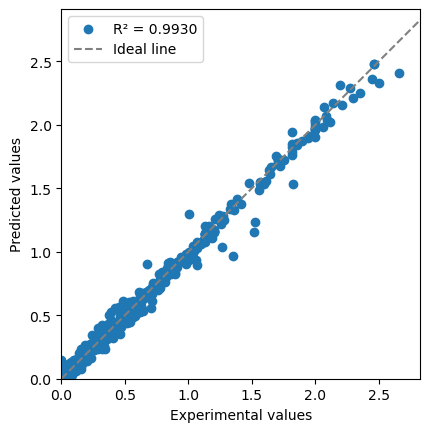

In [15]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

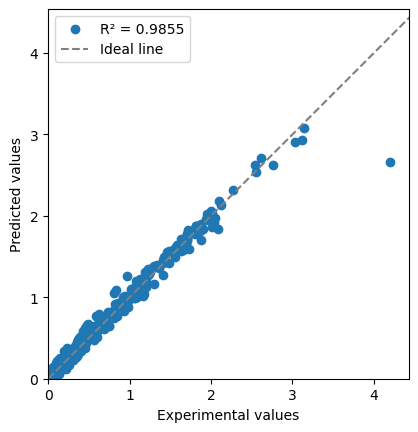

In [16]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values

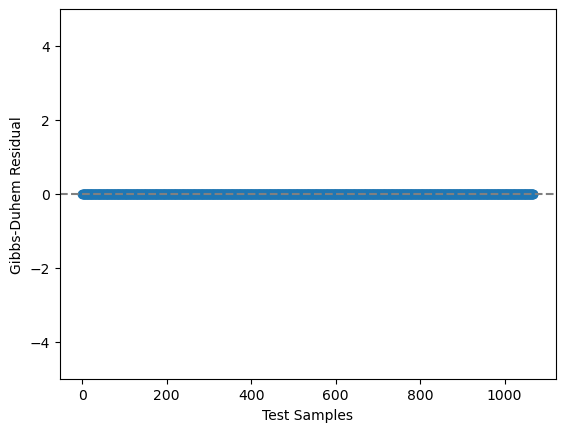

In [17]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Create index for each test sample
test_idxs = np.arange(len(np_gd_residuals))

# Plot residuals against observation index
plt.scatter(test_idxs, np_gd_residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.ylim(-5, 5)
plt.xlabel("Test Samples")
plt.ylabel("Gibbs-Duhem Residual")
plt.show()

Evaluating the distribution of Gibbs-Duhem Residual Values

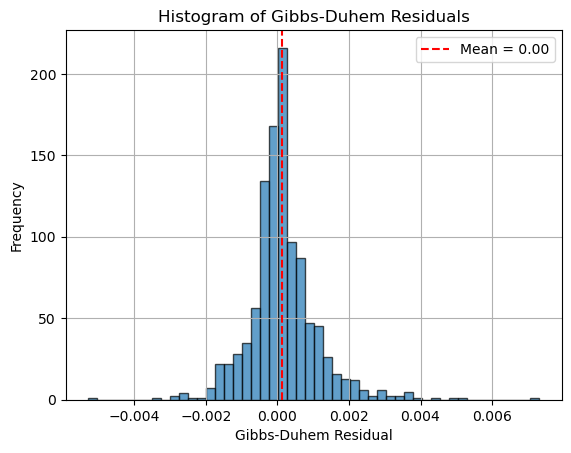

In [18]:
# Compute mean of residuals
mean_residual = np.mean(np_gd_residuals)

# Plot histogram
plt.hist(np_gd_residuals, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}"
)
plt.xlabel("Gibbs-Duhem Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Gibbs-Duhem Residuals")
plt.legend()
plt.grid(True)
plt.show()

### PINN Comparison with Purely Data-Driven Neural Networks

In this section, we train the same architecture without the lambda_gd​ term, which embeds physics into the neural network's loss function. This allows us to compare the residuals between the physics-informed and purely data-driven approaches.

Define the hyperparameters

In [19]:
lr = study.best_params["learning_rate"]
lambda_gd = 0  # Set to zero to remove the physics
lambda_l1 = study.best_params["lambda_l1"]

Evaluating the neural network with the selected hyperparameters, using the same data which trained the PINN

In [20]:
# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
nn_model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
nn_optimizer = torch.optim.Adam(nn_model.parameters(), lr=lr)

# Early stopping setup
nn_best_val_loss = float("inf")
nn_best_model_state = None
nn_patience = EPOCHS / 10
nn_patience_counter = 0

for epoch in range(EPOCHS):
    # Training
    nn_model.train()
    nn_outputs = nn_model(X_train_tensor)
    nn_loss = gibbs_duhem_loss(
        nn_outputs, y_train_tensor, X_train_tensor, nn_model, lambda_gd, lambda_l1
    )[0]

    nn_optimizer.zero_grad()
    nn_loss.backward()
    nn_optimizer.step()

    # Validation
    nn_model.eval()
    nn_val_outputs = nn_model(X_val_tensor)
    nn_val_loss = gibbs_duhem_loss(
        nn_val_outputs,
        y_val_tensor,
        X_val_tensor,
        nn_model,
        lambda_gd,
        lambda_l1,
    )[0]

    if nn_val_loss.item() < nn_best_val_loss:
        nn_best_val_loss = nn_val_loss.item()
        nn_best_model_state = nn_model.state_dict()
        nn_patience_counter = 0
    else:
        nn_patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}: Training loss -> {nn_loss.item():.4f}, Validation loss -> {nn_val_loss.item():.4f}"
        )

    if nn_patience_counter >= nn_patience:
        print(
            f"Early stopping at epoch {epoch + 1}. Best validation loss: {nn_best_val_loss:.4f}"
        )
        break

# Load best model parameters
if nn_best_model_state is not None:
    nn_model.load_state_dict(nn_best_model_state)

# Final model evaluation
nn_model.eval()
nn_test_outputs = nn_model(X_test_tensor)
nn_test_loss, nn_test_mse, nn_test_gd, nn_test_residuals = gibbs_duhem_loss(
    nn_test_outputs, y_test_tensor, X_test_tensor, nn_model, lambda_gd, lambda_l1
)

print(f"\nFinal Test Loss: {nn_test_loss.item():.4f}")
print(f" - Test MSE Loss: {nn_test_mse.item():.4f}")
print(f" - Test GD Loss: {nn_test_gd.item():.4f}")

Epoch 20: Training loss -> 0.1860, Validation loss -> 0.1809
Epoch 40: Training loss -> 0.1426, Validation loss -> 0.1413
Epoch 60: Training loss -> 0.1175, Validation loss -> 0.1166
Epoch 80: Training loss -> 0.0967, Validation loss -> 0.0951
Epoch 100: Training loss -> 0.0819, Validation loss -> 0.0854
Epoch 120: Training loss -> 0.0687, Validation loss -> 0.0700
Epoch 140: Training loss -> 0.0595, Validation loss -> 0.0559
Epoch 160: Training loss -> 0.0484, Validation loss -> 0.0483
Epoch 180: Training loss -> 0.0467, Validation loss -> 0.0456
Epoch 200: Training loss -> 0.0413, Validation loss -> 0.0395
Epoch 220: Training loss -> 0.0386, Validation loss -> 0.0363
Epoch 240: Training loss -> 0.0335, Validation loss -> 0.0348
Epoch 260: Training loss -> 0.0311, Validation loss -> 0.0328
Epoch 280: Training loss -> 0.0303, Validation loss -> 0.0329
Epoch 300: Training loss -> 0.0288, Validation loss -> 0.0313
Epoch 320: Training loss -> 0.0273, Validation loss -> 0.0275
Epoch 340: T

Save the purely data-driven model. The scaler is not saved separately, as it is the same one used for the PINN model due to the identical data split.

In [21]:
# Save final model
torch.save(nn_model.state_dict(), MODEL_PATH / "trained_nn.pt")

Plotting Predicted vs Experimental Values for $\gamma_1$

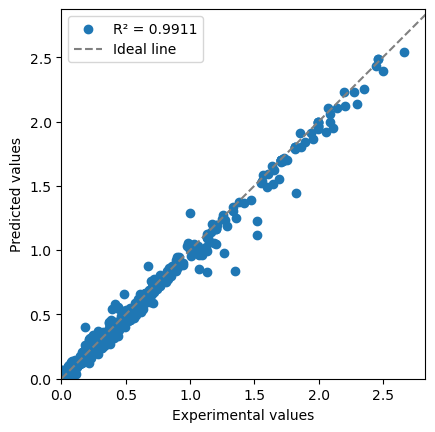

In [22]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(nn_test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = nn_test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

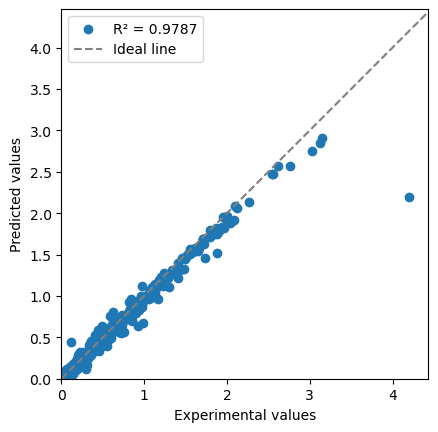

In [23]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(nn_test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = nn_test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values Comparison

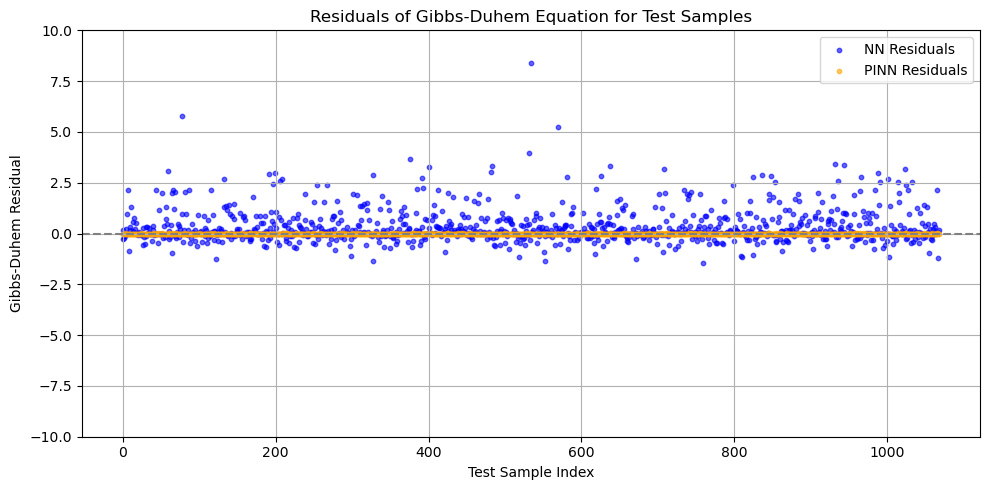

In [24]:
# Convert tensor to NumPy
nn_np_gd_residuals = nn_test_residuals.detach().cpu().numpy()

# Create index for each test sample
nn_test_idxs = np.arange(len(nn_np_gd_residuals))

# Plot residuals
plt.figure(figsize=(10, 5))
plt.scatter(
    nn_test_idxs,
    nn_np_gd_residuals,
    color="blue",
    alpha=0.6,
    label="NN Residuals",
    s=10,
)
plt.scatter(
    test_idxs, np_gd_residuals, color="orange", alpha=0.6, label="PINN Residuals", s=10
)

# Reference line at 0
plt.axhline(0, color="gray", linestyle="--")

# Labels and limits
plt.xlabel("Test Sample Index")
plt.ylabel("Gibbs-Duhem Residual")
plt.title("Residuals of Gibbs-Duhem Equation for Test Samples")
plt.ylim(-10, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Evaluating the distribution of Gibbs-Duhem Residual Values comparison

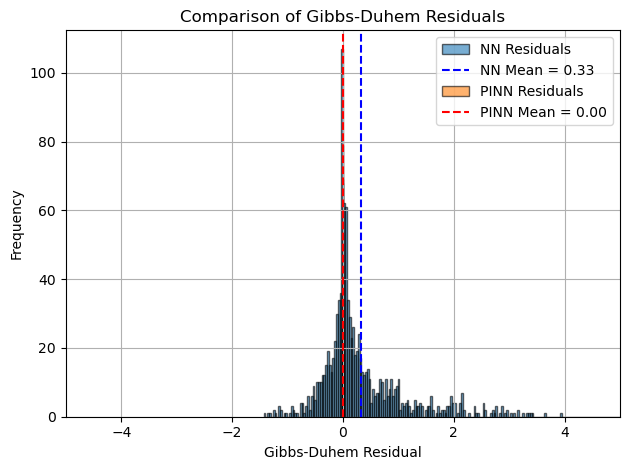

In [25]:
# Compute mean of residuals
nn_mean_residual = np.mean(nn_np_gd_residuals)

# Plot histograms
plt.hist(
    nn_np_gd_residuals, bins=300, edgecolor="black", alpha=0.6, label="NN Residuals"
)
plt.axvline(
    nn_mean_residual,
    color="blue",
    linestyle="--",
    label=f"NN Mean = {nn_mean_residual:.2f}",
)

plt.hist(np_gd_residuals, bins=150, edgecolor="black", alpha=0.6, label="PINN Residuals")
plt.axvline(
    mean_residual, color="red", linestyle="--", label=f"PINN Mean = {mean_residual:.2f}"
)

# Labels and styling
plt.xlabel("Gibbs-Duhem Residual")
plt.ylabel("Frequency")
plt.title("Comparison of Gibbs-Duhem Residuals")
plt.xlim(-5, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()